In [1]:
%load_ext autoreload
%autoreload 2

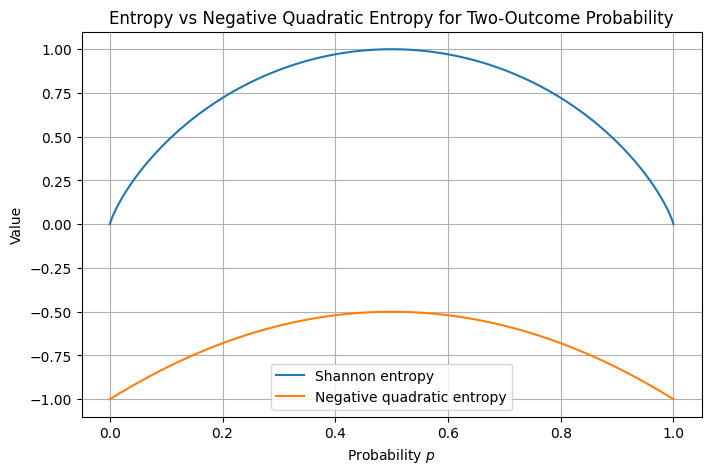

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Probability values (excluding 0 and 1 to avoid log(0))
p = np.linspace(1e-8, 1 - 1e-8, 500)
q = 1 - p

# Entropy H(p) = -p*log2(p) - q*log2(q)
entropy = -p * np.log2(p) - q * np.log2(q)

# Negative quadratic entropy: - (p^2 + q^2)
negative_quadratic_entropy = - (p**2 + q**2)

plt.figure(figsize=(8, 5))
plt.plot(p, entropy, label='Shannon entropy')
plt.plot(p, negative_quadratic_entropy, label='Negative quadratic entropy')
plt.xlabel('Probability $p$')
plt.ylabel('Value')
plt.title('Entropy vs Negative Quadratic Entropy for Two-Outcome Probability')
plt.legend()
plt.grid(True)
plt.show()

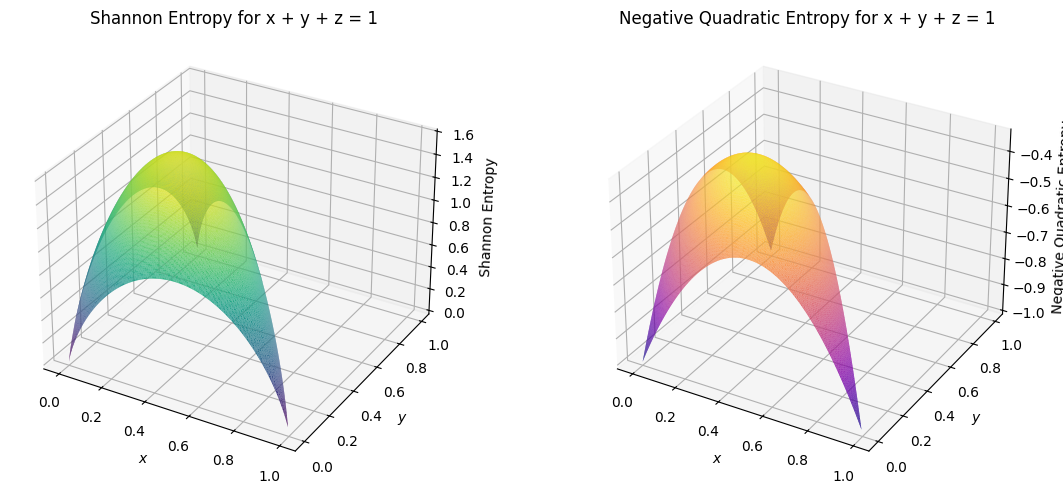

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define grid for x and y in the simplex (0 < x < 1, 0 < y < 1, x + y < 1)
num_points = 200
x = np.linspace(1e-8, 1 - 1e-8, num_points)
y = np.linspace(1e-8, 1 - 1e-8, num_points)
X, Y = np.meshgrid(x, y)
Z = 1 - X - Y

# Mask out invalid values where X + Y >= 1
mask = (Z > 1e-8)
X_valid = X[mask]
Y_valid = Y[mask]
Z_valid = Z[mask]

# Shannon entropy for 3 outcomes: H(p) = -sum p_i log2 p_i
entropy = -(
    X_valid * np.log2(X_valid)
    + Y_valid * np.log2(Y_valid)
    + Z_valid * np.log2(Z_valid)
)

# Negative quadratic entropy: - (x^2 + y^2 + z^2)
negative_quadratic_entropy = - (X_valid**2 + Y_valid**2 + Z_valid**2)

fig = plt.figure(figsize=(12, 5))

# Shannon entropy surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_trisurf(X_valid, Y_valid, entropy, cmap='viridis', linewidth=0.1)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$y$')
ax1.set_zlabel('Shannon Entropy')
ax1.set_title('Shannon Entropy for x + y + z = 1')

# Negative quadratic entropy surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_trisurf(X_valid, Y_valid, negative_quadratic_entropy, cmap='plasma', linewidth=0.1)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$y$')
ax2.set_zlabel('Negative Quadratic Entropy')
ax2.set_title('Negative Quadratic Entropy for x + y + z = 1')

plt.tight_layout()
plt.show()